## **IMPORTING REQUIRED LIBRARIES:**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## **LOADING DATASET:**

In [33]:
df = pd.read_csv("Project_DataSets01.csv")

# **DATA UNDERSTANDING:**

```text
- Before performing data cleaning, we first examine the structure of the dataset to understand the data types, number of entries, and missing values.
```

In [34]:
df.head()

,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals - Hitech City,Hyderabad,96%,Practo,₹800
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,60%,Practo,₹800
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals - Hitech City,Hyderabad,97%,Practo,₹900
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals - Hitech City,Hyderabad,82%,Practo,₹800
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,93%,Practo,₹700


In [35]:
df.tail()

,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
1075,Dr. Sameer Batra,Cardiologist,18,Paras Hospital,Chandigarh,68%,Practo,1300
1076,Dr. Abhishek Jain,Cardiologist,9,Cloudnine Hospital,Chandigarh,72%,Practo,800
1077,Dr. Rohit Tandon,Cardiologist,2,Silver Oaks Hospital,Chandigarh,90%,Practo,900
1078,Dr. Gaurav Arora,Cardiologist,14,Hope Clinic,Chandigarh,82%,Practo,1000
1079,Dr. Anil Kumar,Cardiologist,4,Apollo Hospital,Bangalore,74%,Practo,800


In [36]:
df.shape

(1080, 8)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Doctor_Name       1080 non-null   object
 1   Specialization    1080 non-null   object
 2   Exprience         1080 non-null   int64 
 3   Hospital_Name     1080 non-null   object
 4   City              1080 non-null   object
 5   Patient_Like      939 non-null    object
 6   Info_Source       1080 non-null   object
 7   Consultation_Fee  1080 non-null   object
dtypes: int64(1), object(7)
memory usage: 67.6+ KB


In [38]:
df.describe()

,Exprience
count,1080.000000
mean,23.458333
std,10.246459
min,2.000000
25%,16.000000
50%,22.000000
75%,29.000000
max,65.000000


# **DATA CLEANING:**

### **1. `Checking Missing Values`**
- Missing values are identified to determine whether they need to be handled or removed before analysis.

In [39]:
df.isnull().sum()

Doctor_Name           0
Specialization        0
Exprience             0
Hospital_Name         0
City                  0
Patient_Like        141
Info_Source           0
Consultation_Fee      0
dtype: int64

### **2. `Handling Missing Values`**

- After checking missing values in the dataset, it was observed that the **Patient_Like** column contains **101 missing values**.

- The values in this column are in the form of percentages such as **"96%"**, **"87%"**, etc. Because of the percentage symbol (%), the column is treated as a **string (object datatype)** instead of a numeric datatype.

- For performing numerical analysis, the column must be converted into a numeric format. Therefore, the following steps were performed:

```text
1. First, the **percentage symbol (%) was removed** from the Patient_Like column.
2. Then the column was **converted into numeric datatype**.
3. After conversion, the missing values were **replaced using the median value** of the column to maintain dataset consistency.
```

This ensures that the Patient_Like column can be used for further analysis and visualization.

In [40]:
df["Patient_Like"] = df["Patient_Like"].str.replace("%","")

In [41]:
df["Patient_Like"] = df["Patient_Like"].astype(float)

In [42]:
df["Patient_Like"] = df["Patient_Like"].fillna(df["Patient_Like"].median())

In [43]:
df.head()

,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals - Hitech City,Hyderabad,96.0,Practo,₹800
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,60.0,Practo,₹800
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals - Hitech City,Hyderabad,97.0,Practo,₹900
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals - Hitech City,Hyderabad,82.0,Practo,₹800
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,93.0,Practo,₹700


In [44]:
df["Patient_Like"]

0       96.0
1       60.0
2       97.0
3       82.0
4       93.0
        ... 
1075    68.0
1076    72.0
1077    90.0
1078    82.0
1079    74.0
Name: Patient_Like, Length: 1080, dtype: float64

```text
- After cleaning the Patient_Like column and converting it into numeric format, it was observed that the column still contains missing values.
- Instead of removing these rows (which would reduce the dataset size), the missing values are replaced using the **median value** of the Patient_Like column. 
- The median is used because it is less affected by extreme values and helps maintain the overall distribution of the data.
```

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Doctor_Name       1080 non-null   object 
 1   Specialization    1080 non-null   object 
 2   Exprience         1080 non-null   int64  
 3   Hospital_Name     1080 non-null   object 
 4   City              1080 non-null   object 
 5   Patient_Like      1080 non-null   float64
 6   Info_Source       1080 non-null   object 
 7   Consultation_Fee  1080 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 67.6+ KB


In [46]:
df.isnull().sum()

Doctor_Name         0
Specialization      0
Exprience           0
Hospital_Name       0
City                0
Patient_Like        0
Info_Source         0
Consultation_Fee    0
dtype: int64

### **3. `Cleaning Consultation Fee Column`**
```text
- The Consultation_Fee column contains values such as "₹800", "₹600", and some entries like "Free Consultation".
- Since "Free Consultation" is a text value, it cannot be converted into numeric format. Therefore, it is replaced with ₹0.
- After that, the rupee symbol (₹) is removed and the column is converted into numeric datatype for further analysis.
```

In [16]:
df["Consultation_Fee"] = df["Consultation_Fee"].replace("Free Consultation","₹0")

In [17]:
df["Consultation_Fee"] = df["Consultation_Fee"].str.replace("₹","")

In [18]:
df["Consultation_Fee"] = df["Consultation_Fee"].astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Doctor_Name       1080 non-null   object 
 1   Specialization    1080 non-null   object 
 2   Exprience         1080 non-null   int64  
 3   Hospital_Name     1080 non-null   object 
 4   City              1080 non-null   object 
 5   Patient_Like      1080 non-null   float64
 6   Info_Source       1080 non-null   object 
 7   Consultation_Fee  1080 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 67.6+ KB


In [47]:
df["Consultation_Fee"] 

0       ₹800
1       ₹800
2       ₹900
3       ₹800
4       ₹700
        ... 
1075    1300
1076     800
1077     900
1078    1000
1079     800
Name: Consultation_Fee, Length: 1080, dtype: object

### **4. `Cleaning Hospital Name Column`**
```text
- The Hospital_Name column contains hospital names along with location details such as area names (for example: "Medicover Hospitals - Hitech City").
- For better analysis and to avoid unnecessary variations in hospital names, the location part after "-" is removed, keeping only the main hospital name.
```

In [48]:
df["Hospital_Name"] = df["Hospital_Name"].str.split("-").str[0]

In [49]:
df.head()

,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals,Hyderabad,96.0,Practo,₹800
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,60.0,Practo,₹800
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals,Hyderabad,97.0,Practo,₹900
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals,Hyderabad,82.0,Practo,₹800
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,93.0,Practo,₹700


### **5. `Checking Duplicate Records`**
```text
- Duplicate records were checked in the dataset using the duplicated() function.
- The result shows that there are no duplicate rows present in the dataset.  
  Therefore, no duplicate records needed to be removed.
```

In [50]:
df.duplicated().sum()

np.int64(0)

***"Dataset contains only unique records."***

### **6. `Outlier Detection using IQR Method`**

- Outliers are extreme values that differ significantly from other observations in the dataset.  
- These values can affect statistical analysis and visualizations.

To detect outliers in the **Consultation_Fee** column, the **Interquartile Range (IQR)** method is used.
```text
The IQR method works as follows:

    Q1 (First Quartile) represents the 25th percentile of the data.
    Q3 (Third Quartile) represents the 75th percentile of the data.
    IQR is calculated as the difference between Q3 and Q1.
```
```text
                                                Formula:
```

$$
IQR = Q3 − Q1
$$

```text
        Using the IQR value, the lower and upper bounds are calculated:
```
$$
\text{Lower Bound} = Q1 − 1.5 × IQR
$$
$$
\text{Upper Bound} = Q3 + 1.5 × IQR
$$
```text
    Any values falling outside these bounds are considered potential outliers.
```

In [24]:
Q1 = df["Consultation_Fee"].quantile(0.25)
Q3 = df["Consultation_Fee"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Consultation_Fee"] < lower) | (df["Consultation_Fee"] > upper)]

outliers


,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
16,Dr. Supratip Kundu,Cardiologist,17,Techno India Dama Healthcare & Medical Centre,Kolkata,89.0,Practo,2500
52,Dr. Rajanikanth C. R.,Cardiologist,36,Surana Sethia Hospital and Research Center,Mumbai,91.0,Practo,2000
53,Dr. Ramesh Kawar,Cardiologist,38,Surana Hospital And Research Center,Mumbai,80.0,Practo,2000
54,Dr. Anuj Bhasin,Cardiologist,28,Platinum Hospital,Mumbai,82.0,Practo,2000
55,Dr. Ravi Gupta,Cardiologist,30,Surana Sethia Hospital and Research Center,Mumbai,95.0,Practo,2500
57,Dr. Gangurde Pranil Bhalchandra,Cardiologist,18,A1 Superspeciality Healthcare,Mumbai,95.0,Practo,2000
58,Dr. Vivek Agarwal,Cardiologist,18,Surana Hospital And Research Center,Mumbai,95.0,Practo,2000
67,Dr. Tejas M Patel,Cardiologist,36,Apex Heart Institute,Ahmedabad,71.0,Practo,2200
269,Dr. Amrendra kumar,Dermatologist,19,Dermaclinix,Delhi,93.0,Practo,2000
382,Dr. (Major) Rajesh Kr. Bhardwaj,ENT,31,Med First ENT Center,Delhi,97.0,Practo,3000


- **Outlier Observations in Consultation_Fee**
```text
The above table displays the records that were identified as potential outliers in the Consultation_Fee column using the Interquartile Range (IQR) method.
These values represent doctors whose consultation fees are significantly higher than the majority of doctors in the dataset.

However, these values are not considered data errors. In the healthcare industry, consultation fees can vary depending on factors such as:

- Doctor's experience
- Hospital reputation
- Medical specialization
- City or location of practice

Since these values represent realistic consultation fees charged by experienced doctors or reputed hospitals, the outliers were not removed from the dataset. Keeping these values helps maintain the real-world pricing variation in the healthcare market.
```

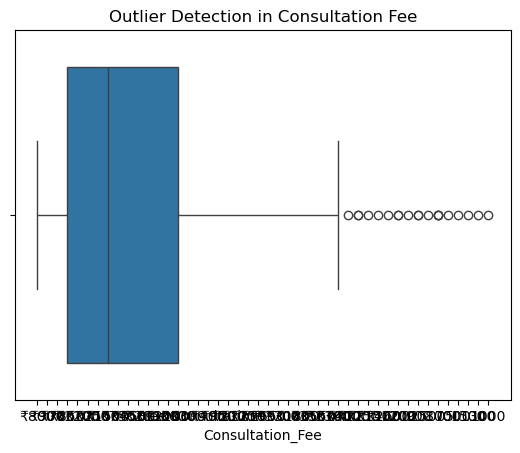

In [52]:
sns.boxplot(x=df["Consultation_Fee"])
plt.title("Outlier Detection in Consultation Fee")
plt.show()

In [26]:
Q1 = df["Patient_Like"].quantile(0.25)
Q3 = df["Patient_Like"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Patient_Like"] < lower) | (df["Patient_Like"] > upper)]

outliers


,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,60.0,Practo,800
33,Dr. Navjeet Singh Ahluwalia,Cardiologist,37,Kalra Hospitals,Delhi,33.0,Practo,1000
34,Dr. Nishant Verma,Cardiologist,20,Cygnus MLS Superspecility Hospital,Delhi,50.0,Practo,500
36,Dr. Ajay Dua,Cardiologist,25,Mata Roop Rani Maggo Hospital and IVF Centre,Delhi,65.0,Practo,1000
66,Dr. Zeeshan Hasan Mansuri,Cardiologist,11,ABC Heart and Skin Care,Ahmedabad,67.0,Practo,1000
...,...,...,...,...,...,...,...,...
1071,Dr. Rajat Mehta,Cardiologist,12,Fortis Hospital,Chandigarh,66.0,Practo,700
1072,Dr. Kunal Sharma,Cardiologist,8,Max Super Speciality,Chandigarh,59.0,Practo,1200
1074,Dr. Nitin Malhotra,Cardiologist,16,IVY Hospital,Chandigarh,64.0,Practo,1500
1075,Dr. Sameer Batra,Cardiologist,18,Paras Hospital,Chandigarh,68.0,Practo,1300


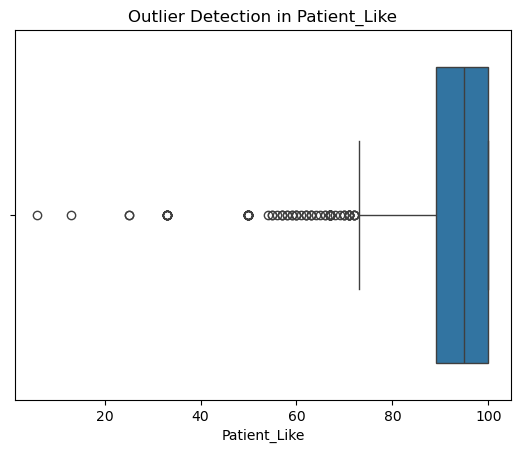

In [51]:
sns.boxplot(x=df["Patient_Like"])
plt.title("Outlier Detection in Patient_Like")
plt.show()

- **Outlier Detection in Patient_Like Column**
```text
The boxplot above shows the distribution of the Patient_Like column and helps identify potential outliers.

Some values appear on the lower side of the distribution, indicating doctors who received comparatively lower patient satisfaction percentages. These values are detected as outliers because most doctors in the dataset have patient review percentages between 80% and 100%.

However, these lower values do not represent data errors. They reflect genuine patient feedback where some doctors received lower satisfaction ratings.

Therefore, these observations were not removed from the dataset, as they represent realistic variations in patient reviews and are important for maintaining the authenticity of the data.
```

In [53]:
df.head()

,Doctor_Name,Specialization,Exprience,Hospital_Name,City,Patient_Like,Info_Source,Consultation_Fee
0,Dr. Anil Krishna Gundala,Cardiologist,23,Medicover Hospitals,Hyderabad,96.0,Practo,₹800
1,Dr. Sai Ravi Shanker A,Cardiologist,31,Aster Prime Hospital,Hyderabad,60.0,Practo,₹800
2,Dr. R. Balaji,Cardiologist,37,Medicover Hospitals,Hyderabad,97.0,Practo,₹900
3,Dr. Krishna Prasad A R,Cardiologist,32,Medicover Hospitals,Hyderabad,82.0,Practo,₹800
4,Dr. Shiva Prasad Koyalakonda,Cardiologist,23,One Cardiac Centre,Hyderabad,93.0,Practo,₹700


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Doctor_Name       1080 non-null   object 
 1   Specialization    1080 non-null   object 
 2   Exprience         1080 non-null   int64  
 3   Hospital_Name     1080 non-null   object 
 4   City              1080 non-null   object 
 5   Patient_Like      1080 non-null   float64
 6   Info_Source       1080 non-null   object 
 7   Consultation_Fee  1080 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 67.6+ KB


### **7. `Exporting File as (.csv)`**

In [55]:
df.to_csv("Project_DataSets02.csv", index=False)